# Download the data

(1) Download the datafile called `hippocampal_neurons.npy` and `mouse_position.npy` from elearning (week 6) to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load both `npy` datafiles by clicking `Choose Files` and navigating to the folder to which you downloaded the files. You should see the file being loaded in google colab. You're all set to move on!

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mouse_position.npy to mouse_position.npy


# Load the data

In [ ]:
import numpy as np
response = np.load('hippocampal_neurons.npy', allow_pickle=True)
position = np.load('mouse_position.npy')

# Create useful variables

In [ ]:
[n_timepoints, n_neurons] = np.shape(response)
pos_min, pos_max = np.nanmin(position), np.nanmax(position)
nbins = 30
bin_edges = np.linspace(np.min(position), np.max(position), nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_idx = np.digitize(position, bin_edges) - 1
bin_idx[bin_idx < 0] = 0
bin_idx[bin_idx >= nbins] = nbins - 1

# Import useful libraries

In [ ]:
from scipy.linalg import lstsq
from scipy.optimize import minimize
from scipy.special import gammaln
from matplotlib import pyplot as plt

# Pick a neuron

In [ ]:
neuron_idx = 100 #np.random.randint(n_neurons)

# Model 1: Influence of position

In [ ]:
x1 = position.astype(float)
y1 = response[:, neuron_idx].astype(float)
eps = 1e-8
X1 = np.column_stack([np.ones_like(x1), x1, x1**2])
z1 = np.log(y1 + eps)
beta1, _, _, _ = lstsq(X1, z1)
c0_1 = beta1[0]
c1_1 = beta1[1]
c2_1 = beta1[2]
log_rate1 = X1 @ beta1
resid1 = z1 - log_rate1
sigma2_resid1 = np.var(resid1)
rate1 = np.exp(log_rate1 + 0.5 * sigma2_resid1)
rate1 = np.clip(rate1, 1e-12, None)
if c2_1 < 0: sigma1 = np.sqrt(-1.0 / (2.0 * c2_1)); mu1 = c1_1 * sigma1**2; A1 = np.exp(c0_1 + mu1**2 / (2.0 * sigma1**2)); print("\nModel 1 coefficients"); print("c0 =", c0_1); print("c1 =", c1_1); print("c2 =", c2_1); print("A =", A1); print("mu =", mu1); print("sigma =", sigma1)
if c2_1 >= 0: print("\nModel 1 coefficients"); print("c0 =", c0_1); print("c1 =", c1_1); print("c2 =", c2_1); print("Warning: quadratic not downward opening")
ll1 = np.sum(y1 * np.log(rate1) - rate1 - gammaln(y1 + 1))
print("Log-likelihood = ", ll1)


Model 1 coefficients
c0 = -18.375237917081922
c1 = 0.0015857185351030399
c2 = -1.990744202292564e-06
A = 1.4350749924202041e-08
mu = 398.2728000103952
sigma = 501.1610060350217
Log-likelihood =  -3066.415573536347


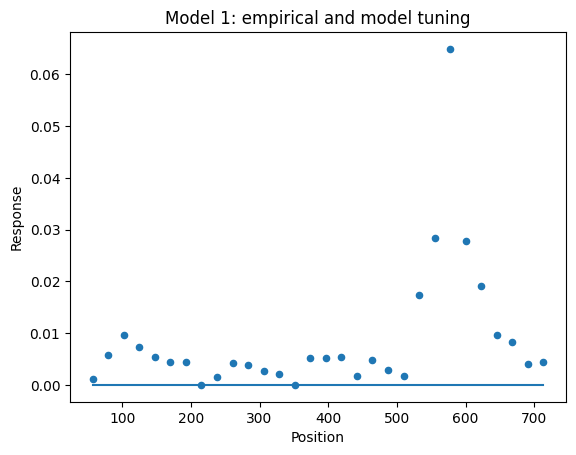

In [ ]:
# plot
emp_tuning1 = np.array([np.mean(y1[bin_idx == k]) if np.any(bin_idx == k) else np.nan for k in range(nbins)])
model_tuning1 = np.exp(c0_1 + c1_1 * bin_centers + c2_1 * bin_centers**2 + 0.5 * sigma2_resid1)
plt.figure()
plt.scatter(bin_centers, emp_tuning1, s=20)
plt.plot(bin_centers, model_tuning1)
plt.xlabel('Position')
plt.ylabel('Response')
plt.title('Model 1: empirical and model tuning')
plt.show()

# Model 2: Influence of other neurons (Linear regression model)

In [ ]:
y2 = response[:, neuron_idx].astype(float)
other_mask2 = np.arange(response.shape[1]) != neuron_idx
other_neurons2 = response[:, other_mask2].astype(float)
X2 = np.column_stack([np.ones(y2.shape[0]), other_neurons2])
beta2, _, _, _ = lstsq(X2, y2)
c0_2 = beta2[0]
w_2 = beta2[1:]
rate2 = X2 @ beta2
rate2 = np.clip(rate2, 1e-12, None)
print("\nModel 2 coefficients")
print("c0 =", c0_2)
print("number of other-neuron weights =", len(w_2))
ll2 = np.sum(y2 * np.log(rate2) - rate2 - gammaln(y2 + 1))
print("Log-likelihood = ", ll2)


Model 2 coefficients
c0 = 0.0030856016606486897
number of other-neuron weights = 187
Log-likelihood =  -1093.1400385185018


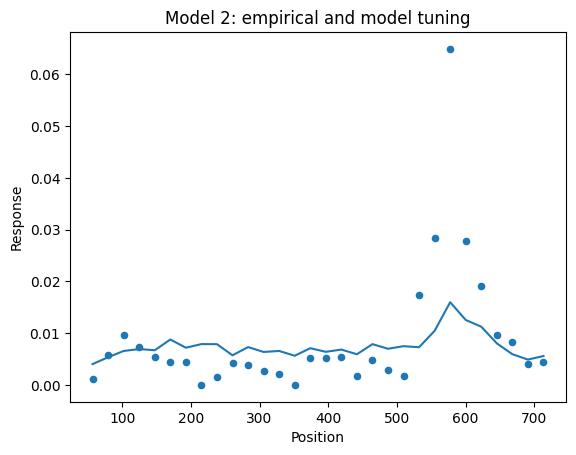

In [ ]:
# plot
emp_tuning2 = np.array([np.mean(y2[bin_idx == k]) if np.any(bin_idx == k) else np.nan for k in range(nbins)])
model_tuning2 = np.array([np.mean(rate2[bin_idx == k]) if np.any(bin_idx == k) else np.nan for k in range(nbins)])
plt.figure()
plt.scatter(bin_centers, emp_tuning2, s=20)
plt.plot(bin_centers, model_tuning2)
plt.xlabel('Position')
plt.ylabel('Response')
plt.title('Model 2: empirical and model tuning')
plt.show()

# Model 3: Influence of other neurons (Generalized Linear model)

In [ ]:
T = 1000
response = response[:T]
position = position[:T]
y3 = response[:, neuron_idx].astype(float)
other_mask3 = np.arange(response.shape[1]) != neuron_idx
other_neurons3 = response[:, other_mask3].astype(float)
other_mean3 = np.mean(other_neurons3, axis=0)
other_std3 = np.std(other_neurons3, axis=0) + 1e-12
other_scaled3 = (other_neurons3 - other_mean3) / other_std3
X3 = np.column_stack([np.ones(y3.shape[0]), other_scaled3])

def neg_loglik(beta):
  eta = X3 @ beta; eta = np.clip(eta, -50, 50)
  lam = np.exp(eta)
  return -np.sum(y3 * np.log(lam + 1e-12) - lam - gammaln(y3 + 1))

beta0_3 = np.zeros(X3.shape[1])
beta0_3[0] = np.log(np.mean(y3) + 1e-8)
res3 = minimize(neg_loglik, beta0_3)
beta3 = res3.x
c0_3 = beta3[0]
w_3 = beta3[1:]
eta3 = np.clip(X3 @ beta3, -50, 50)
rate3 = np.exp(eta3)
rate3 = np.clip(rate3, 1e-12, None)
print("\nModel 3 coefficients")
print("c0 =", c0_3)
print("number of other-neuron weights =", len(w_3))
print("optimizer success =", res3.success)
print("optimizer message =", res3.message)
ll3 = np.sum(y3 * np.log(rate3) - rate3 - gammaln(y3 + 1))
print("Log-likelihood = ", ll3)


Model 3 coefficients
c0 = -229.6010867545185
number of other-neuron weights = 187
optimizer success = False
optimizer message = Desired error not necessarily achieved due to precision loss.
Log-likelihood =  -15.8774477555882


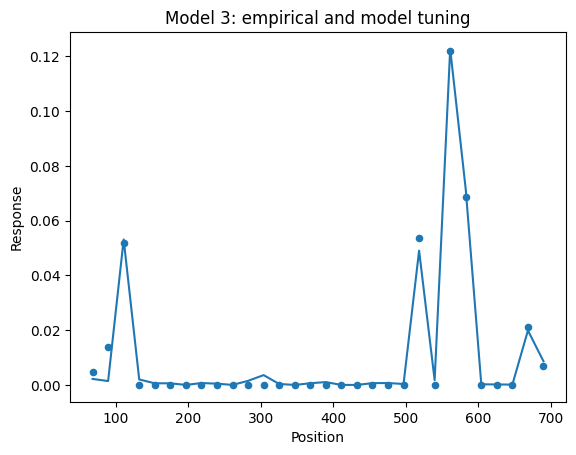

In [ ]:
# plot
bin_edges3 = np.linspace(np.min(position), np.max(position), nbins + 1)
bin_centers3 = 0.5 * (bin_edges3[:-1] + bin_edges3[1:])
bin_idx3 = np.digitize(position, bin_edges3) - 1
bin_idx3[bin_idx3 < 0] = 0
bin_idx3[bin_idx3 >= nbins] = nbins - 1
emp_tuning3 = np.array([np.mean(y3[bin_idx3 == k]) if np.any(bin_idx3 == k) else np.nan for k in range(nbins)])
model_tuning3 = np.array([np.mean(rate3[bin_idx3 == k]) if np.any(bin_idx3 == k) else np.nan for k in range(nbins)])
plt.figure()
plt.scatter(bin_centers3, emp_tuning3, s=20)
plt.plot(bin_centers3, model_tuning3)
plt.xlabel('Position')
plt.ylabel('Response')
plt.title('Model 3: empirical and model tuning')
plt.show()